# **Modelo de Gradient Boosting Classified**
### **Cargar datos**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

ruta_datos_limpios = '../data/datos_limpios_multivariado.csv'
df = pd.read_csv(ruta_datos_limpios)

### **Modelo**

In [ ]:
# Copia del dataset
df_encoded = df.copy()

# Columnas de entrada (features) y objetivo (target)
features = ['gender', 'age', 'financial_label', 'education_label']
target = 'ch_situation_label'

# Codificar features categóricas
label_encoders = {}
for col in features:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

# Codificar variable objetivo si es texto
if df_encoded[target].dtype == 'object':
    le_target = LabelEncoder()
    df_encoded[target] = le_target.fit_transform(df_encoded[target])
else:
    le_target = None

In [19]:
# Entrenamiento / prueba
X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predicción
y_pred = gb_model.predict(X_test)
# Reporte
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=le_target.classes_ if le_target else sorted(y.unique())))


Reporte de clasificación:

               precision    recall  f1-score   support

       hybrid       0.00      0.00      0.00      1326
    in_person       0.56      0.73      0.63      5809
not_in_school       0.00      0.00      0.00       800
       remote       0.51      0.54      0.52      4845

     accuracy                           0.54     12780
    macro avg       0.27      0.32      0.29     12780
 weighted avg       0.45      0.54      0.49     12780



c:\Users\andy-\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\andy-\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\andy-\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

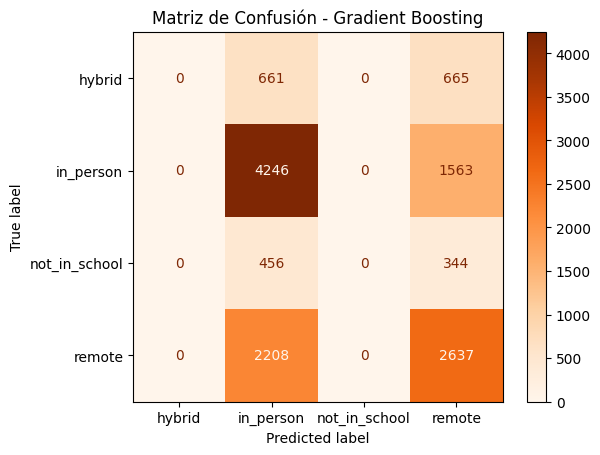

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_ if le_target else sorted(y.unique()))
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusión - Gradient Boosting")
plt.grid(False)
plt.show()

C:\Users\andy-\AppData\Local\Temp\ipykernel_26056\113724473.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='YlOrBr')


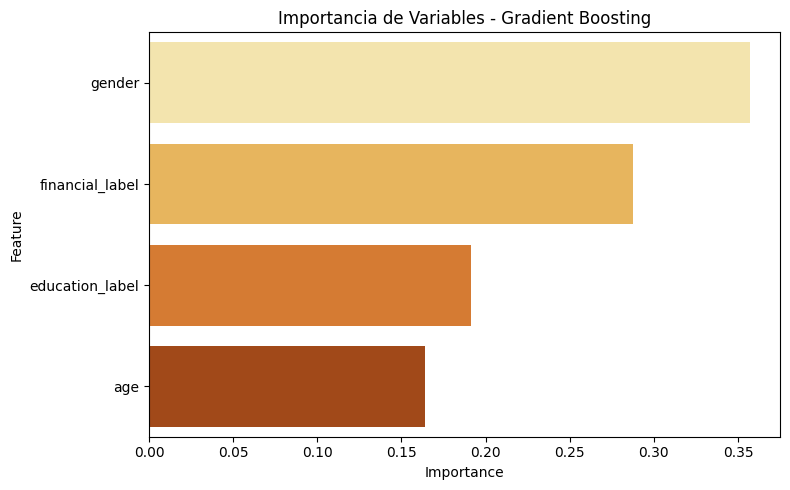

In [21]:
importances = gb_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='YlOrBr')
plt.title("Importancia de Variables - Gradient Boosting")
plt.tight_layout()
plt.show()

## Comparación de Modelos de Clasificación

Se entrenaron tres modelos distintos para predecir la situación educativa de los niños en función de variables socioeconómicas y demográficas:

1. **Decision Tree**
2. **Random Forest**
3. **Gradient Boosting Classifier**

### Variables utilizadas

Cada modelo fue entrenado con un conjunto reducido de variables consideradas relevantes: `gender`, `age`, `financial_label`, `education_label`

### Resultados Comparativos

| Modelo               | Accuracy | F1-score (Macro) | F1-score (Weighted) |
|----------------------|----------|------------------|----------------------|
| **Decision Tree**     | 0.54     | 0.33             | 0.49                 |
| **Random Forest**     | 0.41     | 0.33             | 0.44                 |
| **Gradient Boosting** | **0.54** | 0.29             | **0.49**             |

### Análisis

- El modelo Gradient Boosting logró el mayor accuracy (0.54) y el mayor f1-score ponderado (0.49), lo que indica un mejor rendimiento global al considerar la distribución real de clases.
- El modelo Decision Tree empató en accuracy con Gradient Boosting y también obtuvo un f1 ponderado de 0.49, aunque su desempeño fue ligeramente más equilibrado en términos de f1 macro.
- El modelo Random Forest tuvo el peor rendimiento general entre los tres, a pesar de que es habitualmente más robusto. Su precisión bajó al trabajar con pocas variables.

### Conclusión

- Gradient Boosting es el modelo con mejor rendimiento general, siendo competitivo tanto en precisión como en cobertura de clases.
- El Árbol de Decisión mostró un buen balance con resultados aceptables y puede ser preferible si se busca mayor interpretabilidad.
- Random Forest, a pesar de su potencial, no superó a los otros dos modelos en este caso específico.